Implementation of Ordinary Least Squares.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def load_data(filename):
  data=pd.read_csv(filename)
  x1=data['x1'].values
  x2=data['x2'].values
  y=data['y'].values

  y=y.reshape(-1,1)

  return x1,x2,y,data

In [ ]:
x1,x2,y,data=load_data('/content/drive/MyDrive/LR_train_data.csv')
x1_test,x2_test,y_test,data_test=load_data('/content/drive/MyDrive/LR_test_data.csv')

X_test=np.zeros((len(x1_test),2))
Y_test=y_test.reshape(-1,1)

# Randomly splitting the training and validation set
data_train=data.sample(frac=0.8,random_state=60)
data_val=data.drop(data_train.index)

X_train=data_train[['x1','x2']].values
Y_train=data_train['y'].values

X_validation=data_val[['x1','x2']].values
Y_validation=data_val['y'].values

# Calculating the mean of training set
x1_mean=np.mean(X_train[:,0])
x2_mean=np.mean(X_train[:,1])
y_mean=np.mean(Y_train)

# Centering the training data set
X_train[:,0]=X_train[:,0]-x1_mean
X_train[:,1]=X_train[:,1]-x2_mean
Y_train=Y_train-y_mean
Y_train=Y_train.reshape(-1,1)

# Centering the validation data set
X_validation[:,0]=X_validation[:,0]-x1_mean
X_validation[:,1]=X_validation[:,1]-x2_mean
Y_validation=Y_validation-y_mean
Y_validation=Y_validation.reshape(-1,1)

# Centering the test data set
X_test[:,0]=x1_test-x1_mean
X_test[:,1]=x2_test-x2_mean
Y_test=y_test-y_mean

print("Train Data Shapes")
print("X_train:",X_train.shape ) # should be 80, 2
print("Y_train:" ,Y_train.shape) # should be 80, 1

print("Validation Data Shapes")
print("X_validation:", X_validation.shape) #should be 20,2
print("Y_validation:", Y_validation.shape) #should be 20,1

print("Test Data Shapes ")
print("X_test:", X_test.shape) #should be 50, 2
print("Y_test:", Y_test.shape) #should be 50, 1

Train Data Shapes
X_train: (80, 2)
Y_train: (80, 1)
Validation Data Shapes
X_validation: (20, 2)
Y_validation: (20, 1)
Test Data Shapes 
X_test: (50, 2)
Y_test: (50, 1)


In [ ]:
def ols(X,Y):
  # returns the beta values using the ordinary least squares closed form solution (X^T@X)^-1@X@y
  Xt=X.transpose() #calculating the transpose
  XtX=Xt@X #calculating the Xt*X
  Xty=Xt@Y #calculating Xt*y

  beta_ols=np.linalg.pinv(XtX)@Xty #calculating the beta values pinv is used as XtX might be singular for higher degrees
  return beta_ols


In [ ]:
def poly_regression(X, degree):
    N = X.shape[0]
    X_poly = [np.ones((N, 1))]

    for i in range(1, degree + 1):
        for j in range(i + 1):
            term = (X[:, 0] ** (i - j)) * (X[:, 1] ** j)
            X_poly.append(term.reshape(-1, 1))

    return np.hstack(X_poly)

In [ ]:
def mse(X,Y,beta):
  return np.mean((X@beta-Y)**2)
# Returns the mean squared error

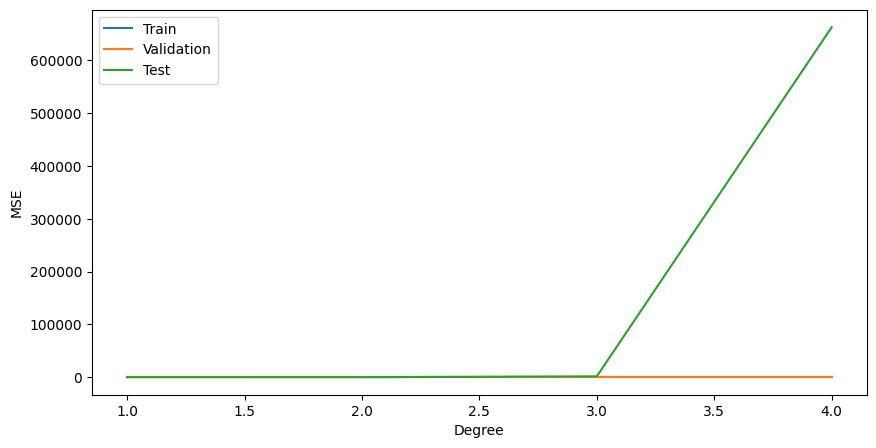

In [ ]:
degrees = list(range(1,5))
mses_train=[]
mses_val=[]
mses_test=[]

for d in degrees:
  # Finding the mean square error for various degree polynomials
  X_train_poly=poly_regression(X_train,d)
  X_validation_poly=poly_regression(X_validation,d)
  X_test_poly=poly_regression(X_test,d)

  beta_ols=ols(X_train_poly,Y_train)

  mses_train.append(mse(X_train_poly,Y_train,beta_ols))
  mses_val.append(mse(X_validation_poly,Y_validation,beta_ols))
  mses_test.append(mse(X_test_poly,Y_test,beta_ols))

fig=plt.figure(figsize=(10,5))
plt.plot(degrees,mses_train)
plt.plot(degrees,mses_val)
plt.plot(degrees,mses_test)
plt.legend(['Train','Validation','Test'])
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.show()
